# 첫 구매 지연 경험 → 재구매 여부 추적

## 분석 목적
신규 고객의 **첫 구매(첫 주문)** 가 배송 지연되었을 때,
이후 **재구매로 이어지는지**를 추적(track)한다.
*"첫인상(첫 배송 경험)이 고객의 재방문을 좌우하는가?"* 를 시간 흐름까지 포함해 확인한다.

## 왜 '첫 구매' 기준인가
한 고객이 여러 번 주문하면 *주문이 많을수록 지연을 겪을 확률*도 올라가, 단순히
"지연 경험 여부"로 묶으면 **인과 방향이 뒤섞인다**(재구매 고객이 자동으로 지연 그룹에 분류됨).
그래서 **모든 고객을 첫 주문이라는 동일한 출발선**에 세우고,
첫 주문의 배송 품질만으로 그룹을 나눠 이후 행동을 추적한다.

## 분석 데이터
- `olist_order_item_level.csv` (본 노트북과 같은 폴더) — 모든 경로는 **상대 경로** 사용

## 추적(Tracking) 구성
| 단계 | 추적 내용 |
|------|-----------|
| 1 | 첫 주문 **지연 여부**별 재구매율 (정시 vs 지연) |
| 2 | 첫 주문 **지연 정도**(일수 구간)별 재구매율 — 용량-반응 |
| 3 | **재구매까지 걸린 시간**(time-to-repurchase) 분포 비교 |
| 4 | **재구매 누적 추적 곡선** — 첫 주문 후 경과일에 따른 누적 재구매율 |
| 5 | **획득 코호트(월)별** 첫 주문 지연/정시 재구매율 추이 |
| 6 | **카이제곱 검정** — 첫 주문 지연 ↔ 재구매 관계의 유의성 |


## 0. 환경 설정 및 시각화 서식 통일

`funnel_delay_1` 과 동일한 서식을 사용해 노트북 간 형식을 통일한다.
- 한글 폰트 **Malgun Gothic** + seaborn `whitegrid`
- 그룹 고정 색상 `PALETTE` (지연=빨강, 정시=초록), 공통 `FIGSIZE`, `annotate_bars()` 헬퍼


In [1]:
# 기본 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 경로 / 통계
from pathlib import Path
from scipy import stats

# 한글 그래프 폰트 설정 - Windows/Jupyter
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

# ── 시각화 공통 서식 (funnel_delay_1 과 동일) ──────────────────────
PALETTE = {"지연 경험": "#C0392B", "정시 배송": "#2E7D5B"}   # 그룹별 고정 색상
ORDER   = ["정시 배송", "지연 경험"]                          # 축/범례 순서 고정
FIGSIZE = (8, 5)                                              # 단일 그래프 기본 크기
TITLE_FS, LABEL_FS = 14, 12                                   # 폰트 크기 통일

def annotate_bars(ax, fmt="{:.1%}", fontsize=12):
    """막대 위에 값 라벨을 통일된 형식으로 표기."""
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom",
                        fontsize=fontsize, fontweight="bold")

print("✅ 환경 설정 완료 / 폰트:", plt.rcParams["font.family"])

✅ 환경 설정 완료 / 폰트: ['Malgun Gothic']


## 1. 데이터 불러오기 & 주문 단위 정제

`funnel_delay_1` 과 동일한 정제 규칙을 적용한다.
1. `order_id` 중복 제거(주문-상품 → 주문 단위)
2. 배송 완료(`is_delivered`) & 정상 주문(`anomaly_flag == 0`)만 사용
3. 지연 일수(`late_days = 실제 도착일 − 예정일`) 계산
4. 구매 시각(`purchase_ts`) 파싱


In [2]:
# 상대 경로 사용
DATA_PATH = "olist_order_item_level.csv"
raw = pd.read_csv(DATA_PATH)
print(f"원본 shape : {raw.shape[0]:,} 행 × {raw.shape[1]} 열")

# 주문 단위 + 배송완료 + 정상 주문
order_level = raw.drop_duplicates(subset="order_id").copy()
order_level = order_level[
    order_level["is_delivered"].eq(True)
    & order_level["anomaly_flag"].eq(0)
].copy()

# 지연 일수 / 구매 시각
delivered = pd.to_datetime(order_level["order_delivered_customer_date"], errors="coerce")
estimated = pd.to_datetime(order_level["order_estimated_delivery_date"], errors="coerce")
order_level["late_days"]   = (delivered - estimated).dt.total_seconds() / 86400
order_level["purchase_ts"] = pd.to_datetime(order_level["order_purchase_timestamp"], errors="coerce")
order_level["is_late"]     = order_level["is_late"].fillna(order_level["late_days"] > 0).astype(bool)

print(f"분석 주문 수 : {order_level['order_id'].nunique():,} 건")
print(f"고유 고객 수 : {order_level['customer_unique_id'].nunique():,} 명")

원본 shape : 112,650 행 × 67 열
분석 주문 수 : 95,082 건
고유 고객 수 : 92,025 명


## 2. 첫 주문 기준 고객 테이블 만들기

고객별로 구매 시각이 가장 빠른 주문을 **첫 주문**으로 정의하고, 추적에 필요한 지표를 만든다.

- `first_ts` : 첫 주문 구매 시각 (= 코호트 진입 시점)
- `first_late` / `first_late_days` : 첫 주문 지연 여부 / 지연 일수
- `second_ts` : 두 번째 주문 구매 시각 (없으면 결측)
- `repurchased` : 두 번째 주문 존재 여부
- `days_to_repurchase` : 첫 주문 → 재구매까지 걸린 일수


In [3]:
# 구매 시각 순 정렬 후 고객 내 순번 부여
order_sorted = order_level.sort_values("purchase_ts").copy()
order_sorted["order_rank"] = order_sorted.groupby("customer_unique_id").cumcount()

# 첫 주문 / 두 번째 주문 추출
first_o  = order_sorted[order_sorted["order_rank"] == 0].copy()
second_o = (order_sorted[order_sorted["order_rank"] == 1]
            [["customer_unique_id", "purchase_ts"]]
            .rename(columns={"purchase_ts": "second_ts"}))

# 고객 테이블 구성
cust = first_o[["customer_unique_id", "purchase_ts", "is_late", "late_days"]].rename(
    columns={"purchase_ts": "first_ts", "is_late": "first_late", "late_days": "first_late_days"}
)
cust = cust.merge(second_o, on="customer_unique_id", how="left")

cust["repurchased"] = cust["second_ts"].notna()
cust["days_to_repurchase"] = (cust["second_ts"] - cust["first_ts"]).dt.total_seconds() / 86400

# 그룹 라벨(서식 통일용)
label_map = {True: "지연 경험", False: "정시 배송"}
cust["first_grp"] = cust["first_late"].astype(bool).map(label_map)

print(f"전체(첫 주문) 고객 수 : {len(cust):,} 명")
print(f"재구매 고객 수        : {cust['repurchased'].sum():,} 명")
print(f"전체 재구매율         : {cust['repurchased'].mean():.2%}")
cust.head()

전체(첫 주문) 고객 수 : 92,025 명
재구매 고객 수        : 2,744 명
전체 재구매율         : 2.98%


,customer_unique_id,first_ts,first_late,first_late_days,second_ts,repurchased,days_to_repurchase,first_grp
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09-15 12:16:38,True,36.324745,NaT,False,NaN,지연 경험
1,32ea3bdedab835c3aa6cb68ce66565ef,2016-10-03 09:44:50,False,-0.415127,2017-09-27 08:20:09,True,358.941192,정시 배송
2,2f64e403852e6893ae37485d5fcacdaf,2016-10-03 16:56:50,False,-10.236366,NaT,False,NaN,정시 배송
3,61db744d2f835035a5625b59350c6b63,2016-10-03 21:13:36,False,-25.542975,NaT,False,NaN,정시 배송
4,8d3a54507421dbd2ce0a1d58046826e0,2016-10-03 22:06:03,False,-22.536319,NaT,False,NaN,정시 배송


## 3. [추적 1] 첫 주문 지연 여부별 재구매율

첫 주문이 **지연된 고객**과 **정시 도착한 고객**의 재구매율을 비교한다.


,그룹,고객수,재구매고객수,재구매율
0,정시 배송,84455,2554,0.030241
1,지연 경험,7570,190,0.025099


첫 주문 정시 재구매율 : 3.02%
첫 주문 지연 재구매율 : 2.51%
상대 격차            : -17.0%  (정시 대비)


C:\Users\함다연\AppData\Local\Temp\ipykernel_17232\2350512686.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grp, x="그룹", y="재구매율", order=ORDER, palette=PALETTE, ax=ax)


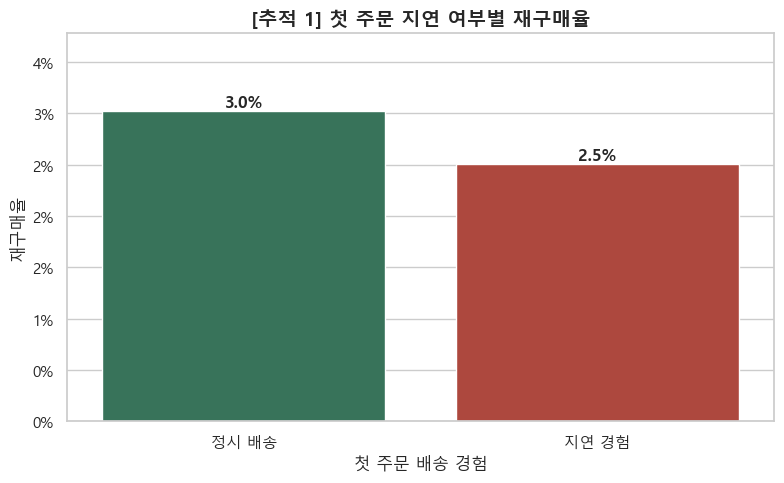

In [4]:
grp = (
    cust.groupby("first_grp")
    .agg(고객수=("customer_unique_id", "count"),
         재구매고객수=("repurchased", "sum"),
         재구매율=("repurchased", "mean"))
    .reindex(ORDER).reset_index().rename(columns={"first_grp": "그룹"})
)
display(grp)

r_on   = grp.loc[grp["그룹"] == "정시 배송", "재구매율"].iloc[0]
r_late = grp.loc[grp["그룹"] == "지연 경험", "재구매율"].iloc[0]
print(f"첫 주문 정시 재구매율 : {r_on:.2%}")
print(f"첫 주문 지연 재구매율 : {r_late:.2%}")
print(f"상대 격차            : {(r_late - r_on) / r_on:+.1%}  (정시 대비)")

# ── 시각화 (통일 서식) ──
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(data=grp, x="그룹", y="재구매율", order=ORDER, palette=PALETTE, ax=ax)
annotate_bars(ax)
ax.set_title("[추적 1] 첫 주문 지연 여부별 재구매율", fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("첫 주문 배송 경험", fontsize=LABEL_FS)
ax.set_ylabel("재구매율", fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, grp["재구매율"].max() * 1.25)
plt.tight_layout(); plt.show()

## 4. [추적 2] 첫 주문 지연 *정도* 별 재구매율

지연이 **심할수록** 재구매율이 더 낮아지는지(용량-반응) 첫 주문 지연 일수를 구간화해 확인한다.
- 음수 = 예정보다 빨리 도착, 양수 = 예정보다 늦게 도착


,지연 구간,고객수,재구매율
0,정시/조기,84455,0.030241
1,1~3일 지연,2563,0.024190
2,4~7일 지연,1763,0.023823
3,8~14일 지연,1735,0.026513
4,15일+ 지연,1509,0.026508


C:\Users\함다연\AppData\Local\Temp\ipykernel_17232\2738695641.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grp_dose, x="지연 구간", y="재구매율", palette=colors, ax=ax)


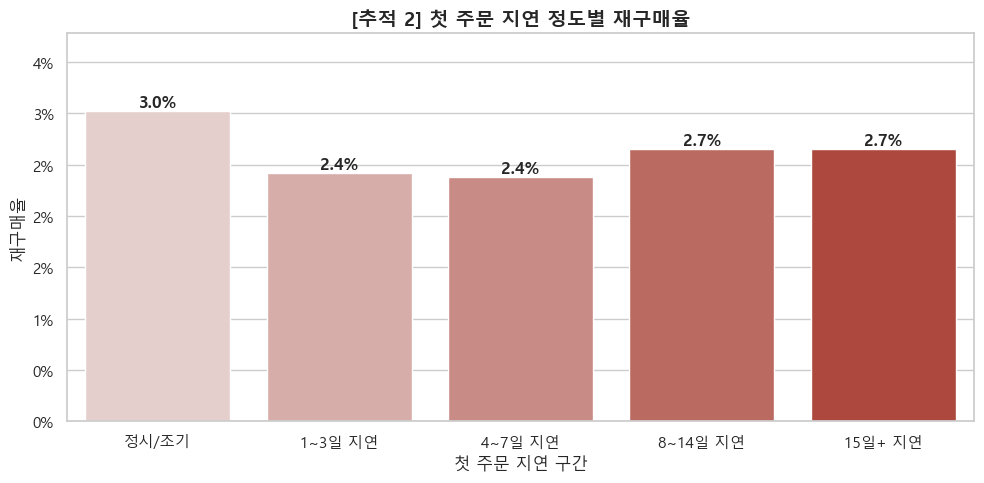

In [5]:
bins   = [-np.inf, 0, 3, 7, 14, np.inf]
labels = ["정시/조기", "1~3일 지연", "4~7일 지연", "8~14일 지연", "15일+ 지연"]
cust["late_bin"] = pd.cut(cust["first_late_days"], bins=bins, labels=labels)

grp_dose = (
    cust.dropna(subset=["late_bin"])
    .groupby("late_bin", observed=True)
    .agg(고객수=("customer_unique_id", "count"),
         재구매율=("repurchased", "mean"))
    .reset_index().rename(columns={"late_bin": "지연 구간"})
)
display(grp_dose)

# ── 시각화 (통일 서식: 빨강 그라데이션) ──
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.light_palette(PALETTE["지연 경험"], n_colors=len(grp_dose) + 1)[1:]
sns.barplot(data=grp_dose, x="지연 구간", y="재구매율", palette=colors, ax=ax)
annotate_bars(ax)
ax.set_title("[추적 2] 첫 주문 지연 정도별 재구매율", fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("첫 주문 지연 구간", fontsize=LABEL_FS)
ax.set_ylabel("재구매율", fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, grp_dose["재구매율"].max() * 1.25)
plt.tight_layout(); plt.show()

## 5. [추적 3] 재구매까지 걸린 시간 (Time-to-Repurchase)

재구매한 고객만 대상으로, **첫 주문 → 두 번째 주문까지 걸린 일수** 분포를
정시/지연 그룹별로 비교한다.
*"지연을 겪은 고객은 돌아오더라도 더 망설이는가(더 늦게 돌아오는가)?"* 를 본다.


,그룹,재구매고객수,평균일수,중앙값일수
0,정시 배송,2476,71.004854,26.137743
1,지연 경험,188,55.834590,17.279878


C:\Users\함다연\AppData\Local\Temp\ipykernel_17232\3111622829.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=repeat_win, x="first_grp", y="days_to_repurchase",


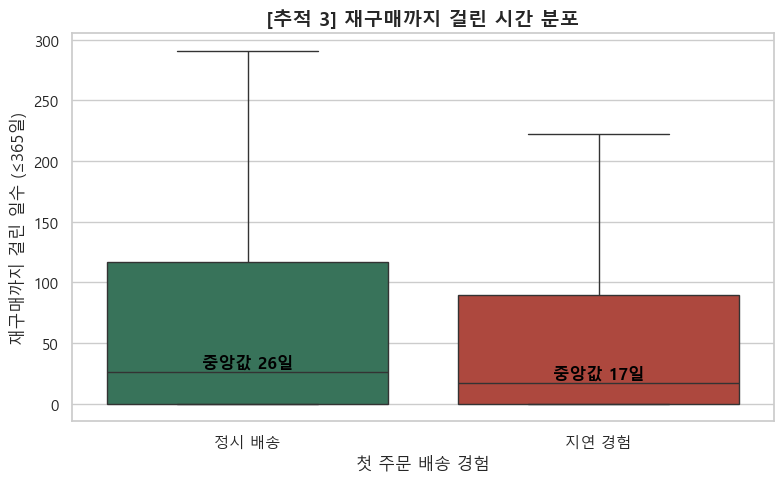

In [6]:
repeat = cust[cust["repurchased"]].copy()
# 극단값 영향 완화를 위해 365일 이내 재구매만 분포 비교에 사용
repeat_win = repeat[repeat["days_to_repurchase"].between(0, 365)]

summary = (
    repeat_win.groupby("first_grp")["days_to_repurchase"]
    .agg(재구매고객수="count", 평균일수="mean", 중앙값일수="median")
    .reindex(ORDER).reset_index().rename(columns={"first_grp": "그룹"})
)
display(summary)

# ── 시각화 (통일 서식: 그룹 색상 동일) ──
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.boxplot(data=repeat_win, x="first_grp", y="days_to_repurchase",
            order=ORDER, palette=PALETTE, showfliers=False, ax=ax)
ax.set_title("[추적 3] 재구매까지 걸린 시간 분포", fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("첫 주문 배송 경험", fontsize=LABEL_FS)
ax.set_ylabel("재구매까지 걸린 일수 (≤365일)", fontsize=LABEL_FS)
# 중앙값 라벨 표기 (통일 형식)
for i, g in enumerate(ORDER):
    med = repeat_win.loc[repeat_win["first_grp"] == g, "days_to_repurchase"].median()
    ax.annotate(f"중앙값 {med:.0f}일", (i, med), ha="center", va="bottom",
                fontsize=12, fontweight="bold", color="black")
plt.tight_layout(); plt.show()

## 6. [추적 4] 재구매 누적 추적 곡선

첫 주문 이후 **경과일(D일)** 에 따라 *"D일 이내에 재구매한 고객 비율"* 이 어떻게 쌓이는지
정시/지연 그룹별로 추적한다.

> ⚠️ **관측기간 편향(우측 절단) 통제** : 데이터 마지막 시점에 가까운 고객은 재구매를 관측할
> 시간이 짧다. 따라서 첫 주문이 *데이터 종료일보다 최소 `WINDOW`일 이전*인 고객만 사용해
> 모두 동일한 관측 기간을 갖도록 맞춘다.


데이터 종료일 : 2018-08-29  /  컷오프 : 2018-03-02
추적 대상 고객 : 55,761 명  (관측기간 180일 동일 보장)


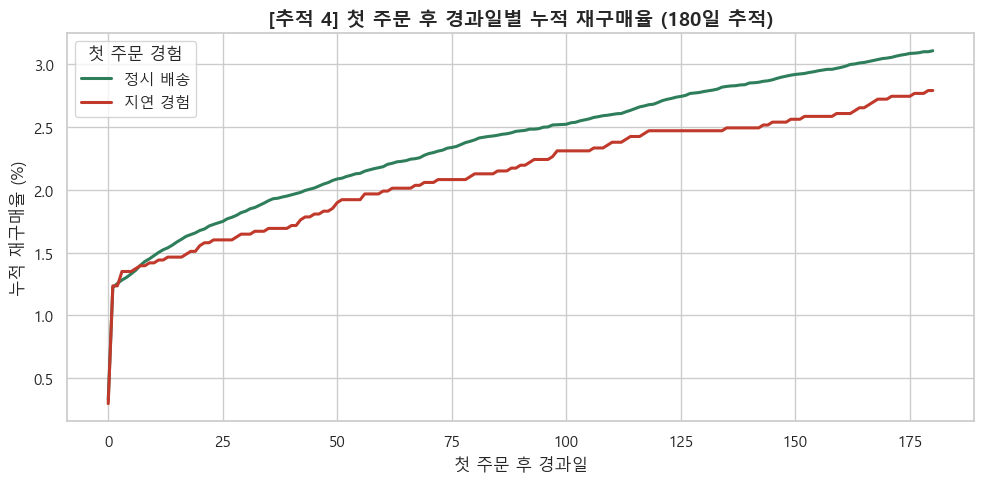

In [7]:
WINDOW = 180  # 모든 고객에게 동일하게 주는 관측 기간(일)
data_end = order_level["purchase_ts"].max()
cutoff = data_end - pd.Timedelta(days=WINDOW)

# 동일 관측 기간이 보장되는 고객만
elig = cust[cust["first_ts"] <= cutoff].copy()
# WINDOW 이내 재구매만 '성공'으로 간주
elig["repurchase_in_window"] = elig["repurchased"] & (elig["days_to_repurchase"] <= WINDOW)

print(f"데이터 종료일 : {data_end.date()}  /  컷오프 : {cutoff.date()}")
print(f"추적 대상 고객 : {len(elig):,} 명  (관측기간 {WINDOW}일 동일 보장)")

# 경과일별 누적 재구매율 계산
days_axis = np.arange(0, WINDOW + 1)
fig, ax = plt.subplots(figsize=(10, 5))
for g in ORDER:
    sub = elig[elig["first_grp"] == g]
    gaps = sub.loc[sub["repurchase_in_window"], "days_to_repurchase"].values
    cum_rate = [(gaps <= d).sum() / len(sub) for d in days_axis]
    ax.plot(days_axis, np.array(cum_rate) * 100, label=g,
            color=PALETTE[g], linewidth=2.2)

ax.set_title(f"[추적 4] 첫 주문 후 경과일별 누적 재구매율 ({WINDOW}일 추적)",
             fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("첫 주문 후 경과일", fontsize=LABEL_FS)
ax.set_ylabel("누적 재구매율 (%)", fontsize=LABEL_FS)
ax.legend(title="첫 주문 경험")
plt.tight_layout(); plt.show()

## 7. [추적 5] 획득 코호트(월)별 재구매율 추이

고객을 **첫 주문 월(획득 코호트)** 로 나눠, 정시/지연 그룹의 재구매율이 시간에 걸쳐
*일관되게* 벌어지는지 추적한다. 특정 시기의 우연이 아니라 **구조적 패턴**인지 확인하는 목적이다.


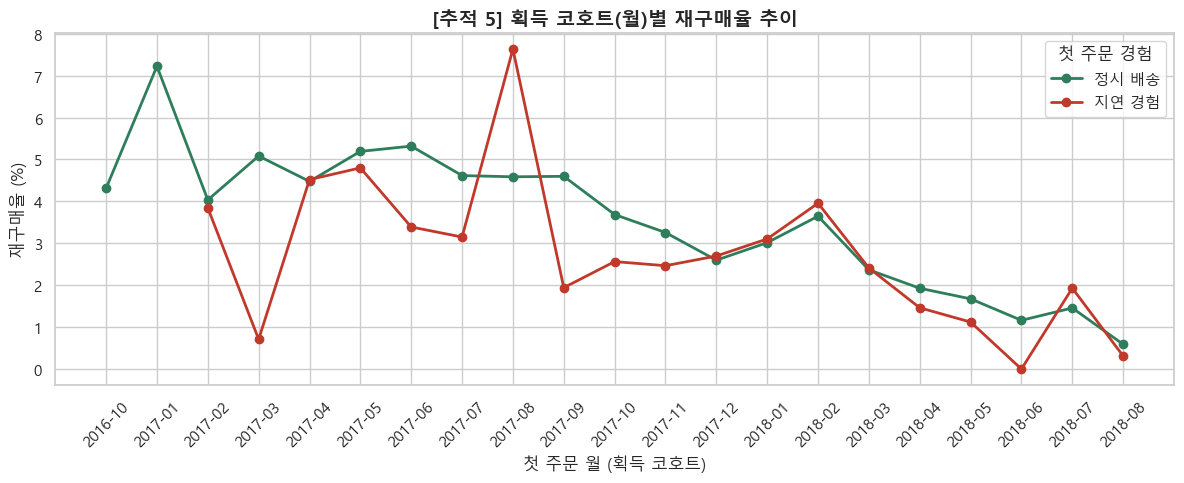

In [8]:
cust["cohort_month"] = cust["first_ts"].dt.to_period("M").astype(str)

cohort = (
    cust.groupby(["cohort_month", "first_grp"])["repurchased"]
    .mean().mul(100).reset_index()
    .rename(columns={"repurchased": "재구매율"})
)
# 표본이 매우 적은 초기/말기 코호트는 노이즈가 크므로 그룹별 30명 이상만 사용
counts = cust.groupby(["cohort_month", "first_grp"])["customer_unique_id"].count().rename("n")
cohort = cohort.merge(counts, on=["cohort_month", "first_grp"])
cohort = cohort[cohort["n"] >= 30]

# ── 시각화 (통일 서식) ──
fig, ax = plt.subplots(figsize=(12, 5))
for g in ORDER:
    sub = cohort[cohort["first_grp"] == g].sort_values("cohort_month")
    ax.plot(sub["cohort_month"], sub["재구매율"], marker="o",
            label=g, color=PALETTE[g], linewidth=2)
ax.set_title("[추적 5] 획득 코호트(월)별 재구매율 추이", fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("첫 주문 월 (획득 코호트)", fontsize=LABEL_FS)
ax.set_ylabel("재구매율 (%)", fontsize=LABEL_FS)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="첫 주문 경험")
plt.tight_layout(); plt.show()

## 8. 통계적 유의성 검정 (카이제곱)

첫 주문 지연 여부와 재구매 여부가 **독립인지** 카이제곱 독립성 검정으로 확인한다.
- H₀ : 첫 주문 지연 여부와 재구매는 독립 (관계 없음)
- H₁ : 둘 사이에 관계가 있다 / p < 0.05 면 H₀ 기각


In [9]:
contingency = pd.crosstab(cust["first_grp"], cust["repurchased"]).reindex(ORDER)
contingency.columns = ["재구매 안함", "재구매 함"]
print("◼ 교차표 (관측 빈도)")
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"카이제곱 통계량 : {chi2:.3f}")
print(f"자유도          : {dof}")
print(f"p-value         : {p_value:.4f}")
print("→", "❗ 통계적으로 유의한 차이 (H0 기각)" if p_value < 0.05
        else "유의한 차이 없음 (H0 기각 불가)")

◼ 교차표 (관측 빈도)


,재구매 안함,재구매 함
first_grp,,
정시 배송,81901,2554
지연 경험,7380,190


카이제곱 통계량 : 6.173
자유도          : 1
p-value         : 0.0130
→ ❗ 통계적으로 유의한 차이 (H0 기각)


## 9. 종합 요약

In [10]:
print("=" * 58)
print(" 첫 구매 지연 경험 → 재구매 추적 — 핵심 요약")
print("=" * 58)
print(f"· 분석(첫 주문) 고객 수 : {len(cust):,} 명")
print(f"· 전체 재구매율         : {cust['repurchased'].mean():.2%}")
print("-" * 58)
print("[추적 1] 첫 주문 지연 여부별 재구매율")
for _, r in grp.iterrows():
    print(f"   - {r['그룹']:<8}: {r['재구매율']:.2%}  (n={r['고객수']:,})")
print(f"   → 첫 주문 지연 시 재구매율 격차 : {(r_late - r_on) / r_on:+.1%} (정시 대비)")
print("[추적 3] 재구매까지 걸린 시간(중앙값)")
for _, r in summary.iterrows():
    print(f"   - {r['그룹']:<8}: {r['중앙값일수']:.0f}일  (n={r['재구매고객수']:,})")
print(f"[검정] 카이제곱 p-value : {p_value:.4f} "
      f"({'유의함' if p_value < 0.05 else '유의하지 않음'})")
print("=" * 58)

 첫 구매 지연 경험 → 재구매 추적 — 핵심 요약
· 분석(첫 주문) 고객 수 : 92,025 명
· 전체 재구매율         : 2.98%
----------------------------------------------------------
[추적 1] 첫 주문 지연 여부별 재구매율
   - 정시 배송   : 3.02%  (n=84,455)
   - 지연 경험   : 2.51%  (n=7,570)
   → 첫 주문 지연 시 재구매율 격차 : -17.0% (정시 대비)
[추적 3] 재구매까지 걸린 시간(중앙값)
   - 정시 배송   : 26일  (n=2,476)
   - 지연 경험   : 17일  (n=188)
[검정] 카이제곱 p-value : 0.0130 (유의함)


### 해석 가이드

- **추적 1** : 첫 주문이 지연된 고객의 재구매율이 정시 그룹보다 낮으면, *나쁜 첫인상이
  재방문을 떨어뜨린다*는 직접 신호다.
- **추적 2** : 지연 일수가 길수록 재구매율이 단조 감소하면, 지연 영향이 *용량-반응* 형태로
  존재한다고 볼 수 있다.
- **추적 3** : 지연 그룹이 *돌아오더라도 더 늦게* 돌아온다면, 지연은 재구매 *발생*뿐 아니라
  *속도*에도 영향을 준다.
- **추적 4(누적 곡선)** : 두 곡선의 벌어짐이 초반부터 꾸준하면, 지연의 부정적 효과가
  첫 주문 직후부터 누적됨을 의미한다. (관측기간을 동일하게 맞춰 절단 편향을 통제함)
- **추적 5(코호트)** : 격차가 여러 코호트에서 일관되면, 특정 시기의 우연이 아니라
  **구조적 패턴**임을 뒷받침한다.

> Olist는 재구매율 자체가 낮은 시장이므로, 절대값보다 **그룹 간 상대 격차**·**추세**·
> **통계적 유의성(검정)** 을 함께 보고 결론을 내린다.


노트북 1이 "지연 경험 여부 비교"(여러 관점의 횡단면 비교)였다면, 노트북 2는 첫 구매라는 단일 출발선에서 시간 흐름까지 추적합니다. 핵심 추가 요소:

추적 3·4 — 단순히 "재구매했는가"를 넘어 언제/얼마나 빨리 돌아오는지를 시계열로 추적
추적 4의 절단 편향 통제 — 데이터 종료일 가까운 고객은 관측 기간이 짧아 재구매가 적게 잡히므로, 첫 주문이 종료일보다 최소 180일 이전인 고객만 골라 모두 동일한 180일 관측 기간을 보장했습니다 (그렇지 않으면 곡선이 왜곡됨)
검증된 결과
추적 1: 첫 주문 정시 3.02% vs 지연 2.51% → 정시 대비 −17%
추적 3: 재구매까지 중앙값 — 정시 26일 vs 지연 17일 (지연 그룹 재구매자 n=188로 표본 작음, 해석 시 유의)
카이제곱 p=0.013 → 통계적으로 유의
한 가지 데이터 특성을 짚어두면: Olist는 전체 재구매율이 ~3%로 매우 낮아 지연 그룹의 재구매자 수(190명)가 적습니다. 그래서 추적 3·5처럼 그룹을 더 쪼개는 분석은 표본이 작아질 수 있어, 해석 가이드에 "절대값보다 상대 격차·추세·유의성을 함께 보라"고 명시했습니다.